# House Prices - Advanced Regression Techniques

Predict sales prices and practice feature engineering, RFs, and gradient boosting

![Descripción de la competición en Kaggle](images/Img1.png)


Predecimos el precio de venta de viviendas. La métrica de Kaggle es el RMSLE: la raíz del error cuadrático medio entre el logaritmo del precio predicho y el logaritmo del precio real.

**Score: 0.11515** en el leaderboard público, Top 1% de la competición, en la posición 56 en el momento de la subida.

El modelo es TabPFN v2. Se ajusta en cinco particiones, con el precio en log1p, y las cinco predicciones del test se promedian.

### Importación


In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "4")
os.environ.setdefault("MKL_NUM_THREADS", "4")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "4")

%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from tabpfn import TabPFNRegressor
from tabpfn.constants import ModelVersion

ROOT = Path.cwd()
DATA = ROOT / "data"

SEED = 42
sns.set_theme(style="whitegrid")


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def kfold():
    return KFold(n_splits=5, shuffle=True, random_state=SEED)


### Carga

In [2]:
train = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")
print(train.shape, test.shape)

train[["Id", "Neighborhood", "OverallQual", "GrLivArea", "SalePrice"]].head()


(1460, 81) (1459, 80)


,Id,Neighborhood,OverallQual,GrLivArea,SalePrice
0,1,CollgCr,7,1710,208500
1,2,Veenker,6,1262,181500
2,3,CollgCr,7,1786,223500
3,4,Crawfor,7,1717,140000
4,5,NoRidge,8,2198,250000


Train trae 1.460 viviendas y el precio. Test trae 1.459 viviendas, sin precio.

### EDA


#### Variable objetivo

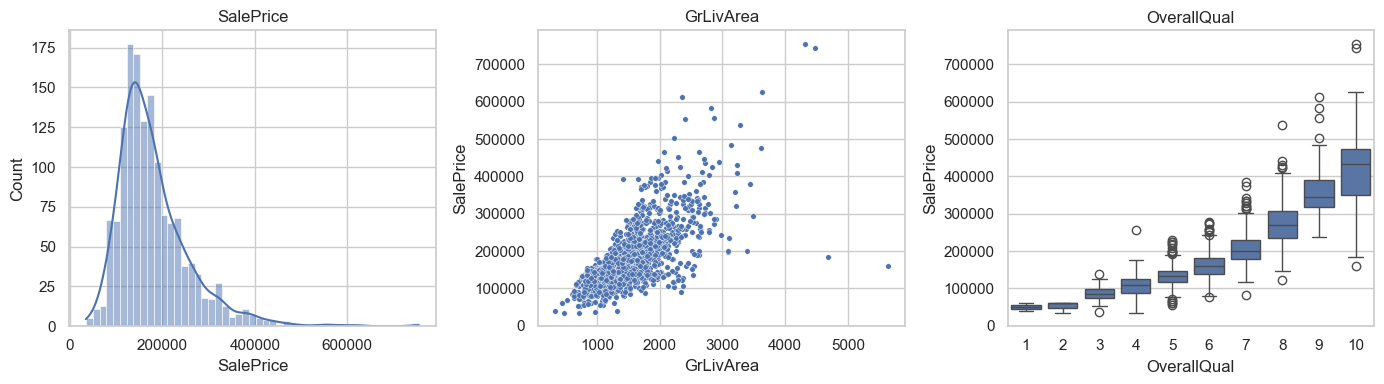

count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(train["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice")
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", ax=axes[1], s=16)
axes[1].set_title("GrLivArea")
sns.boxplot(data=train, x="OverallQual", y="SalePrice", ax=axes[2])
axes[2].set_title("OverallQual")
fig.tight_layout()
plt.show()

print(train["SalePrice"].describe().round(0))


SalePrice está sesgado a la derecha. La mayoría de las casas cae entre 100.000 y 200.000 dólares y la cola pasa de 700.000. 

El modelo usará log1p(SalePrice) y al final se deshará con expm1.

También se detectan outliers que habrá que limpiar.

### Preprocesamiento


#### Outliers

En GrLivArea hay dos casas por encima de 4.000 pies cuadrados vendidas por menos de 300.000 dólares. Se decide eliminar las rows, mientras que el test se queda como está.


In [ ]:
bad = (train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)
train = train.loc[~bad].reset_index(drop=True)

# transformacion logarítmica de la variable objetivo
y = np.log1p(train["SalePrice"].to_numpy(dtype=np.float64))
test_ids = test["Id"].to_numpy()

print(train.shape, test.shape)


(1458, 81) (1459, 80)


#### Missings


In [5]:
missing = train.isna().mean().sort_values(ascending=False)
print(missing[missing > 0].head(12).round(3))


PoolQC          0.996
MiscFeature     0.963
Alley           0.938
Fence           0.807
MasVnrType      0.598
FireplaceQu     0.473
LotFrontage     0.178
GarageYrBlt     0.056
GarageCond      0.056
GarageType      0.056
GarageFinish    0.056
GarageQual      0.056
dtype: float64


En PoolQC, MiscFeature, Alley, Fence, FireplaceQu y en las columnas de garaje y de sótano, el NA significa que ese elemento no existe. Por eso, se crea la categoría "None". Este mismo problema en las numéricas se soluciona de la siguiente manera: GarageArea, GarageCars, las superficies de sótano y MasVnrArea pasan a 0. Si no hay garaje, GarageYrBlt se iguala a YearBuilt.

LotFrontage toma la mediana de Neighborhood en el train. MSZoning, Electrical, KitchenQual, Exterior1st, Exterior2nd y SaleType tienen pocos missings y se rellenan con la moda del train. Functional vacío se deja en Typ.

Utilities casi no varía y se elimina. MSSubClass es un código de clase, no una medida, y pasa a texto. Train y test se tratan juntos. La moda y las medianas salen solo del train.


In [6]:
ntrain = len(train)
all_data = pd.concat(
    [train.drop(columns=["SalePrice", "Id"]), test.drop(columns=["Id"])],
    axis=0,
).reset_index(drop=True)

for col in (
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType",
):
    all_data[col] = all_data[col].fillna("None")

lot_frontage = train.groupby("Neighborhood")["LotFrontage"].median()
all_data["LotFrontage"] = all_data["LotFrontage"].fillna(all_data["Neighborhood"].map(lot_frontage))
all_data["LotFrontage"] = all_data["LotFrontage"].fillna(float(train["LotFrontage"].median()))

for col in (
    "GarageArea", "GarageCars", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
    "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath", "MasVnrArea",
):
    all_data[col] = all_data[col].fillna(0)

all_data["GarageYrBlt"] = all_data["GarageYrBlt"].fillna(all_data["YearBuilt"])

for col in ("MSZoning", "Electrical", "KitchenQual", "Exterior1st", "Exterior2nd", "SaleType"):
    all_data[col] = all_data[col].fillna(train[col].mode(dropna=True).iloc[0])

all_data["Functional"] = all_data["Functional"].fillna("Typ")
all_data = all_data.drop(columns=["Utilities"])
all_data["MSSubClass"] = all_data["MSSubClass"].astype(str)


#### Feature Engineering

TotalSF suma TotalBsmtSF, 1stFlrSF y 2ndFlrSF. 

TotalBath suma los baños completos y da medio punto a HalfBath y BsmtHalfBath. 

TotalPorch junta OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch y WoodDeckSF. 

Age y RemodAge son los años desde YearBuilt y YearRemodAdd hasta YrSold. 

IsNew vale 1 si la casa se vendió el año en que se construyó.


In [7]:
all_data["TotalSF"] = all_data["TotalBsmtSF"] + all_data["1stFlrSF"] + all_data["2ndFlrSF"]
all_data["TotalBath"] = (
    all_data["FullBath"] + 0.5 * all_data["HalfBath"]
    + all_data["BsmtFullBath"] + 0.5 * all_data["BsmtHalfBath"]
)
all_data["TotalPorch"] = (
    all_data["OpenPorchSF"] + all_data["EnclosedPorch"] + all_data["3SsnPorch"]
    + all_data["ScreenPorch"] + all_data["WoodDeckSF"]
)
all_data["Age"] = (all_data["YrSold"] - all_data["YearBuilt"]).clip(lower=0)
all_data["RemodAge"] = (all_data["YrSold"] - all_data["YearRemodAdd"]).clip(lower=0)
all_data["IsNew"] = (all_data["YearBuilt"] == all_data["YrSold"]).astype(np.int64)


#### Categoricas

ExterQual, ExterCond, BsmtQual, BsmtCond, HeatingQC, KitchenQual, FireplaceQu, GarageQual, GarageCond y PoolQC van de None a Ex. 

BsmtExposure, BsmtFinType1, BsmtFinType2, Functional, GarageFinish, Fence, LotShape, LandSlope y PavedDrive tienen su propia escala. CentralAir pasa a 0/1 y Street a Grvl = 0, Pave = 1.

Neighborhood, SaleCondition y las demás categóricas se quedan como texto. Un NA que aún quede en una de ellas pasa a "Missing". Lo que siga vacío en una numérica toma la mediana del train.


In [8]:
# ExterQual, ExterCond, BsmtQual, BsmtCond, HeatingQC, KitchenQual,
# FireplaceQu, GarageQual, GarageCond, PoolQC
QUAL = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
# BsmtExposure
EXPOSURE = {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}
# BsmtFinType1, BsmtFinType2
FIN = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
# Functional
FUNCTIONAL = {
    "None": 0, "Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4,
    "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8,
}
# GarageFinish
GARAGE_FIN = {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3}
# Fence
FENCE = {"None": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4}
# LotShape
LOT_SHAPE = {"None": 0, "IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4}
# LandSlope
SLOPE = {"None": 0, "Sev": 1, "Mod": 2, "Gtl": 3}
# PavedDrive. N y None valen lo mismo.
PAVED = {"None": 0, "N": 0, "P": 1, "Y": 2}

for col, mapping in (
    ("ExterQual", QUAL), ("ExterCond", QUAL), ("BsmtQual", QUAL), ("BsmtCond", QUAL),
    ("HeatingQC", QUAL), ("KitchenQual", QUAL), ("FireplaceQu", QUAL),
    ("GarageQual", QUAL), ("GarageCond", QUAL), ("PoolQC", QUAL),
    ("BsmtExposure", EXPOSURE), ("BsmtFinType1", FIN), ("BsmtFinType2", FIN),
    ("Functional", FUNCTIONAL), ("GarageFinish", GARAGE_FIN), ("Fence", FENCE),
    ("LotShape", LOT_SHAPE), ("LandSlope", SLOPE), ("PavedDrive", PAVED),
):
    all_data[col] = all_data[col].fillna("None").map(mapping).fillna(0).astype(np.int64)

all_data["CentralAir"] = all_data["CentralAir"].map({"N": 0, "Y": 1}).fillna(0).astype(np.int64)
all_data["Street"] = all_data["Street"].map({"Grvl": 0, "Pave": 1}).fillna(1).astype(np.int64)

cat_cols = [
    col for col in all_data.columns
    if all_data[col].dtype == object or str(all_data[col].dtype) == "string"
]
for col in cat_cols:
    all_data[col] = all_data[col].fillna("Missing").astype(str)

for col in all_data.columns:
    if col in cat_cols:
        continue
    all_data[col] = pd.to_numeric(all_data[col], errors="coerce")
    med = float(all_data.loc[: ntrain - 1, col].median())
    if not np.isfinite(med):
        med = 0.0
    all_data[col] = all_data[col].fillna(med)

frame_train = all_data.iloc[:ntrain].reset_index(drop=True)
frame_test = all_data.iloc[ntrain:].reset_index(drop=True)
print(f"{len(cat_cols)} categóricas, {frame_train.shape[1] - len(cat_cols)} numéricas")
print(frame_train.shape, frame_test.shape)


22 categóricas, 62 numéricas
(1458, 84) (1459, 84)


### Modelización

Cada fold entrena un TabPFN v2 y predice las casas que no ha visto. El número de pasos va fijado: no hay early stopping sobre el fold que se puntúa. El test es la media de los cinco modelos.


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device", device)

folds = kfold()
tab_oof = np.zeros(len(y))
tab_test = np.zeros(len(frame_test))
tab_folds = []

for fold, (tr, va) in enumerate(folds.split(frame_train), start=1):
    tab_model = TabPFNRegressor.create_default_for_version(
        ModelVersion.V2,
        device=device,
        random_state=SEED,
        ignore_pretraining_limits=True,
        n_preprocessing_jobs=1,
    )
    tab_model.fit(frame_train.iloc[tr], y[tr])
    pred_va = np.asarray(tab_model.predict(frame_train.iloc[va]), dtype=float).reshape(-1)
    pred_te = np.asarray(tab_model.predict(frame_test), dtype=float).reshape(-1)
    tab_oof[va] = pred_va
    tab_test += pred_te / 5.0
    tab_folds.append(rmse(y[va], pred_va))
    print(f"  tabpfn fold {fold}: {tab_folds[-1]:.5f}", flush=True)
    del tab_model
    if device == "cuda":
        torch.cuda.empty_cache()

print(f"tabpfn   OOF {rmse(y, tab_oof):.5f}")


device cuda


### Submission

In [ ]:
price = np.expm1(tab_test)
submission = pd.DataFrame({"Id": test_ids.astype(int), "SalePrice": price})

submission.to_csv(ROOT / "submission.csv", index=False)

print(f"submission.csv  n={len(price)}")


submission.csv  n=1459  min=45956  max=579532  media=179047


**Esta solución puntuó con 0.11515 en Kaggle.**

![Leaderboard público: posición 56, score 0.11515](images/Img2.png)
